In [8]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import json


In [11]:
cwd = Path(os.getcwd())
print(cwd)

json_path = cwd / 'WS2_Grating_Eamonn' / 'Results' / 'WS₂, SiO₂, Si 4' / 'summary.json'

with open(json_path, 'r') as summary:
    data = json.load(summary)
    print(data)

C:\Users\pha21wh\Desktop\research_project
{'t=100.0nm Λ=300nm FF=0.50 N=75': {'fitting info': {'1': {'R2': 0.9100094071476725, 'popt': [-0.5609136110129909, 6951.578275563136, 9.264037573685778, 1370.0561355644406, 1.6449456078233546, 2.7675094735896444, 0.8823248230302951]}}, 'fitting results': {'vertices': [1.7400826715657964], 'asyms': [-0.9016991650162023]}}, 't=100.0nm Λ=300nm FF=0.55 N=75': {'fitting info': {'1': {'R2': 0.9416260926544842, 'popt': [-0.42974857485375195, 6933.372274918173, 9.286166459437613, 864.2410863199884, 1.2031186599734234, 2.6354627566805804, 0.8442429702033585]}}, 'fitting results': {'vertices': [1.6771084325445458], 'asyms': [-0.2740835592657591]}}, 't=100.0nm Λ=300nm FF=0.60 N=75': {'fitting info': {'1': {'R2': 0.9640502756658124, 'popt': [-0.3499630307010665, 6916.482534899396, 3.6275094203985856, 842.5257636005903, 0.6314822354724846, 1.7264104492719032, 0.815278820825178]}}, 'fitting results': {'vertices': [1.618319014818649], 'asyms': [0.741586036121

[1.8036473760893563, 1.6600269169076889] [-0.14362046]
[1.6982716563645073, 1.616430316224355] [-0.08184134]
[1.6852598388383886, 1.5923674179016165] [-0.09289242]
[1.6719339495001955, 1.5635943355651902] [-0.10833961]
[1.6800602935318465, 1.5592117913252417] [-0.1208485]
[1.6256613773953843, 1.583123627387665] [-0.04253775]
[1.6173873352834476, 1.5655760704537762] [-0.05181126]
[1.6095370327276592, 1.5359121042826904] [-0.07362493]
[1.5950583648349825, 1.517514334680293] [-0.07754403]
[1.6043041952330919, 1.4887509540675898] [-0.11555324]
[1.5948629266398047, 1.4661470543817532] [-0.12871587]
[1.5867252869905872, 1.4038780408836786] [-0.18284725]
[1.548107507245496, 1.3851388750807565] [-0.16296863]
[1.552833163314668, 1.3542534166275324] [-0.19857975]
[1.5231566444173628, 1.320555384395454] [-0.20260126]
[1.4815424446632313, 1.2906002587810044] [-0.19094219]
[1.4418400739173642, 1.2698966588729093] [-0.17194342]
[1.513807473551204, 1.2732753997736406] [-0.24053207]
[1.539080599339743

C:\Users\pha21wh\AppData\Local\Temp\ipykernel_13160\1543486738.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  diff_energy.append(float(np.diff(temp_vertices)))


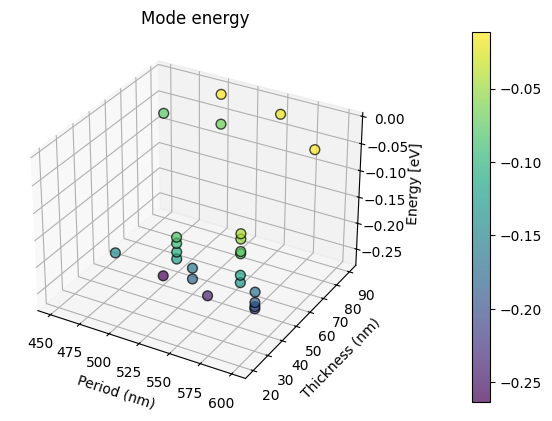

In [58]:
# aim is to plot the mode energies and separation against: period, thickness, filling

# Lists to store filtered data
periods = []
thicknesses = []
mean_energy = []
diff_energy = []

# Extract data
for key, value in data.items():
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        continue
    
   

    temp_vertices:list = []
    temp_thickness:float = None
    temp_period:float = None

    temp_period = float(period)
    temp_thickness = float(thickness)
    
    # Only consider entries with R2 > 0.6
    for i,key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if abs(R2) > 0.6:
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to lists
            temp_vertices.append(vertex)

    if len(temp_vertices) == 2:
        mean_energy.append(np.mean(temp_vertices))
        print(temp_vertices, np.diff(temp_vertices))
        diff_energy.append(float(np.diff(temp_vertices)))
        periods.append(temp_period)
        thicknesses.append(temp_thickness)
    else:
        continue


print((diff_energy))
# Convert lists to numpy arrays for easier manipulation
periods = np.array(periods)
thicknesses = np.array(thicknesses)
energy = np.array(diff_energy)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter1 = ax.scatter(periods, thicknesses, energy, c=energy, 
                      cmap='viridis',
                      marker='o',  # Marker type (circle)
                      s=50,  # Size of markers (points)
                      edgecolor='k',  # Edge color of points (black)
                      alpha=0.7)

fig.colorbar(scatter1)
fig.subplots_adjust(right = 3)
ax.set_xlabel('Period (nm)')
ax.set_ylabel('Thickness (nm)')
ax.set_zlabel('Energy [eV]')
ax.set_title('Mode energy')
plt.show()

C:\Users\pha21wh\AppData\Local\Temp\ipykernel_13160\1660026335.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  diff_energy.append(float(np.diff(temp_vertices)))


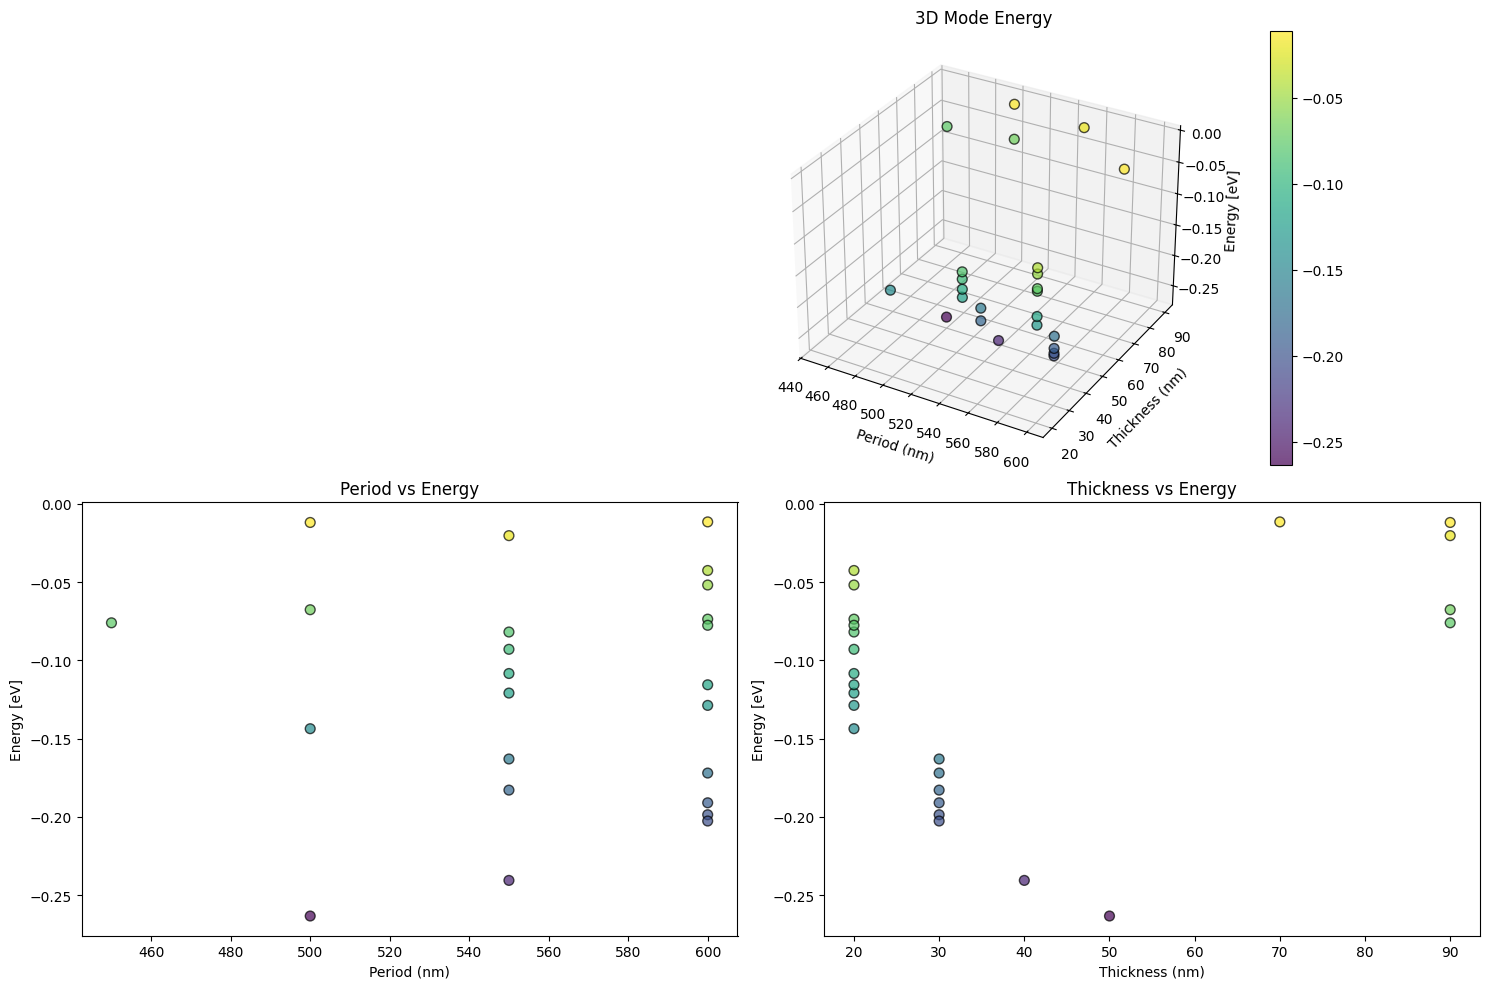

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Lists to store filtered data
periods = []
thicknesses = []
mean_energy = []
diff_energy = []

# Assuming 'data' is your dictionary with the necessary data
for key, value in data.items():
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())

    if len(keys) < 2:
        continue
    
    temp_vertices = []
    temp_thickness = None
    temp_period = None

    temp_period = float(period)
    temp_thickness = float(thickness)
    
    # Only consider entries with R2 > 0.6
    for i, key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if abs(R2) > 0.6:
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to lists
            temp_vertices.append(vertex)

    if len(temp_vertices) == 2:
        mean_energy.append(np.mean(temp_vertices))
        diff_energy.append(float(np.diff(temp_vertices)))
        periods.append(temp_period)
        thicknesses.append(temp_thickness)
    else:
        continue

# Convert lists to numpy arrays for easier manipulation
periods = np.array(periods)
thicknesses = np.array(thicknesses)
energy = np.array(diff_energy)

# Create a figure with 2 rows and 1 column for the 3D plot above and 2D plots below
fig = plt.figure(figsize=(15, 10))

# 3D Plot
ax1 = fig.add_subplot(211, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, energy, c=energy, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
fig.colorbar(scatter1)
ax1.set_xlabel('Period (nm)')
ax1.set_ylabel('Thickness (nm)')
ax1.set_zlabel('Energy [eV]')
ax1.set_title('3D Mode Energy')

# 2D plot for Period vs Energy
ax2 = fig.add_subplot(223)
scatter2 = ax2.scatter(periods, energy, c=energy, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel('Period (nm)')
ax2.set_ylabel('Energy [eV]')
ax2.set_title('Period vs Energy')

# 2D plot for Thickness vs Energy
ax3 = fig.add_subplot(224)
scatter3 = ax3.scatter(thicknesses, energy, c=energy, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel('Thickness (nm)')
ax3.set_ylabel('Energy [eV]')
ax3.set_title('Thickness vs Energy')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


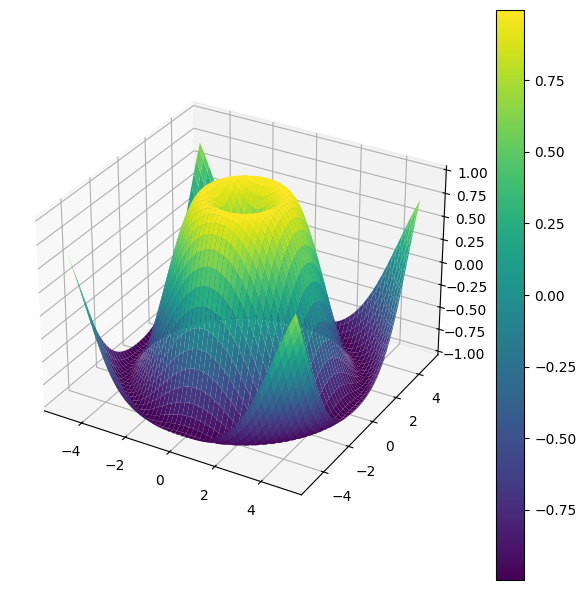

In [20]:
# test 3d plot

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Create a figure
fig = plt.figure(figsize=(12, 6))  # Adjust the figure size for better layout

# Add the first 3D subplot
ax1 = fig.add_subplot(121, projection='3d')  # Use 121 for the first subplot

# Generate data for the plot
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)
z = np.sin(np.sqrt(x**2 + y**2))

# Plot a 3D surface with the viridis colormap on the first subplot
surf1 = ax1.plot_surface(x, y, z, cmap=cm.viridis)

# Add a color bar to provide reference for the colormap of the first plot
fig.colorbar(surf1, ax=ax1)

# Add the second 3D subplot
# ax2 = fig.add_subplot(122, projection='3d')  # Use 122 for the second subplot

# # Plot a 3D surface with the viridis colormap on the second subplot
# surf2 = ax2.plot_surface(x, y, z, cmap=cm.viridis)

# # Add a color bar to provide reference for the colormap of the second plot
# fig.colorbar(surf2, ax=ax2)

# Show the plot
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()